## Polygon Partitioning & Subdivision


### Vocabulary and Problem Context

1. **Region or Input Polygon:**
   - This is the irregular boundary (e.g., your GeoTIFF's extent or another polygon) that you want to partition.
   - Defined as a closed polygonal shape, often represented as a **shapely.geometry.Polygon** or in GeoJSON format.

2. **Partitioning:**
   - The process of dividing the polygon into smaller polygons or subregions.
   - The goal here is to create as many **subregions** as possible, each with a target area (e.g., 1 acre).

3. **Target Area:**
   - The desired area of each subregion. For example, 1 acre (~4046.86 m²).
   - Any remainder will form a smaller subregion.

4. **Compactness:**
   - Refers to the shape of the subregions, favoring more regular (e.g., circular or square-like) shapes.
   - This avoids "spindly" or elongated polygons.

5. **Spatial Packing:**
   - A mathematical problem related to fitting shapes (e.g., circles, hexagons, or squares) into a bounded area with minimal gaps or overlaps.
   - Common approaches include:
     - **Hexagonal Tiling:** Provides the most efficient packing in a 2D plane for compact regions.
     - **Square Grid Tiling:** Easier to compute but less efficient.

6. **Polygon Clipping:**
   - Cutting out portions of shapes when they overlap or exceed the bounds of the region polygon.
   - Libraries like `shapely` or `clipper` are often used for this step.

7. **Centroidal Voronoi Tessellation (CVT):**
   - A more advanced method to partition a region into compact areas of nearly equal size while maintaining adjacency constraints.
   - This method adapts the partition to the specific shape of the input polygon.

8. **Optimization Constraints:**
   - Maximizing the number of subregions while meeting area constraints.
   - Ensuring geometric and topological validity (e.g., no overlaps, no gaps).

---

### Known Solutions and Techniques

1. **Regular Tiling (Hexagonal or Square):**
   - Simpler and faster to compute.
   - Best for polygons that approximate a rectangular or compact shape.
   - Example: Use a grid of hexagons or squares to cover the region, then clip the grid to the polygon.

2. **Voronoi-Based Partitioning:**
   - A dynamic method that adjusts the location of subregions iteratively.
   - Ensures nearly equal areas while conforming to the shape of the polygon.
   - Tools: `scipy.spatial.Voronoi` or `geovoronoi`.

3. **Centroidal Voronoi Tessellation (CVT):**
   - A refinement of Voronoi tessellation that iteratively adjusts cell centroids to equalize areas.
   - Computationally intensive but produces high-quality partitions.

4. **Geometric Optimization:**
   - Use algorithms like **linear programming** or **simulated annealing** to find optimal partition configurations.
   - Useful for irregular polygons where packing circles or squares is challenging.

5. **Shape Packing with Overlap Clipping:**
   - Generate a grid of candidate shapes (e.g., circles) and clip them to the polygon.
   - Sort and validate based on area constraints.

In [2]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

from plant_search.load_image import load_image, plot_image


# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'
file_path = '../input/IGNORE_Brewster-ortho.tif'


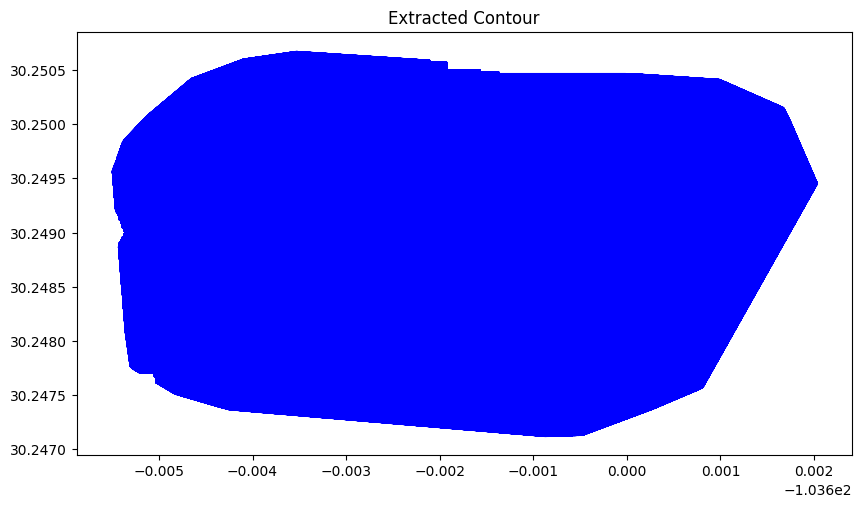

In [ ]:
import rasterio
from rasterio.plot import show
from rasterio.features import shapes
from shapely.geometry import shape, mapping
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from skimage.measure import find_contours
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_erosion
import numpy as np

def region_mask(geotiff_path):
    """
    Generate and plot a mask where RGB values are all zero, or where alpha is one (if present).
    """
    with rasterio.open(geotiff_path) as src:
        # Ensure the GeoTIFF has at least 3 bands (for RGB)
        if src.count < 3:
            raise ValueError("GeoTIFF must have at least 3 bands for RGB.")

        # Read RGB bands
        r = src.read(1)
        g = src.read(2)
        b = src.read(3)

        # Initialize mask where all RGB are zero
        mask = ~( (r == 0) & (g == 0) & (b == 0) )

        # Check for alpha channel (usually the 4th band)
        if src.count >= 4:
            alpha = src.read(4)
            mask |= (alpha == 1)

    # Plot the mask
    # plt.figure(figsize=(10, 10))
    # plt.imshow(mask, cmap="gray")
    # plt.title("Custom Mask (Valid Data Regions)")
    # plt.colorbar(label="Valid Data Mask (True/False)")
    # plt.show()

    return mask

def extract_contour(geotiff_path):
    """
    Extract the contour (outline) of the valid data region from a GeoTIFF.
    
    Parameters:
        geotiff_path (str): Path to the GeoTIFF file.
    
    Returns:
        GeoDataFrame: Contour as a polygon.
    """
    
    mask = region_mask(geotiff_path)
    # Dilate the mask slightly to ensure connected edges
    dilated_mask = binary_dilation(mask)

    with rasterio.open(geotiff_path) as src:
        # Extract the coordinates of the boundary
        contours = []
        for i, row in enumerate(dilated_mask):
            for j, val in enumerate(row):
                if val and not mask[i, j]:  # Edge pixel
                    # Convert row/col to spatial coordinates
                    x, y = src.xy(i, j)
                    contours.append((x, y))

    # Create a polygon from the contour
    contour_polygon = Polygon(contours)

    # Convert to GeoDataFrame
    return gpd.GeoDataFrame({"geometry": [contour_polygon]}, crs=src.crs)


def extract_fast_contour(geotiff_path):
    """
    Quickly extract the outer boundary of a binary mask as a polygon.
    
    Parameters:
        geotiff_path (str): Path to the GeoTIFF file.
    
    Returns:
        GeoDataFrame: Outer boundary as a polygon.
    """
    mask = region_mask(geotiff_path)

    with rasterio.open(geotiff_path) as src:
        # Use skimage to find contours at the 0.5 level
        contours = find_contours(mask, level=0.5)

        # Assume the largest contour is the region of interest
        largest_contour = max(contours, key=len)

        # Convert contour pixel indices to spatial coordinates
        contour_coords = [src.xy(int(y), int(x)) for y, x in largest_contour]
        contour_polygon = Polygon(contour_coords)

    # Convert to GeoDataFrame
    return gpd.GeoDataFrame({"geometry": [contour_polygon]}, crs=src.crs)


def fast_binary_edge(geotiff_path):
    """
    Quickly extract the edge of a binary mask and create a perimeter polygon.
    
    Parameters:
        geotiff_path (str): Path to the GeoTIFF file.
    
    Returns:
        GeoDataFrame: Perimeter as a polygon.
    """
    with rasterio.open(geotiff_path) as src:
        # Read the first band
        data = src.read(1)

        # Create a binary mask for valid data
        mask = (data != 0)

        # Perform binary erosion and find the edge
        eroded_mask = binary_erosion(mask)
        edge_mask = mask & ~eroded_mask  # Pixels on the edge of the valid region

        # Get coordinates of edge pixels
        edge_coords = np.column_stack(np.where(edge_mask))
        
        # Convert pixel indices to spatial coordinates
        edge_coords_spatial = [src.xy(row, col) for row, col in edge_coords]

        # Create a polygon from the edge
        edge_polygon = Polygon(edge_coords_spatial)

    # Convert to GeoDataFrame
    return gpd.GeoDataFrame({"geometry": [edge_polygon]}, crs=src.crs)


# Example usage
# contour_gdf = extract_contour(file_path)
# contour_gdf = extract_fast_contour(file_path)
contour_gdf = fast_binary_edge(file_path)


# Plot the contour
contour_gdf.plot(edgecolor="blue", figsize=(10, 10))
plt.title("Extracted Contour")
plt.show()

# plot_custom_mask(file_path)


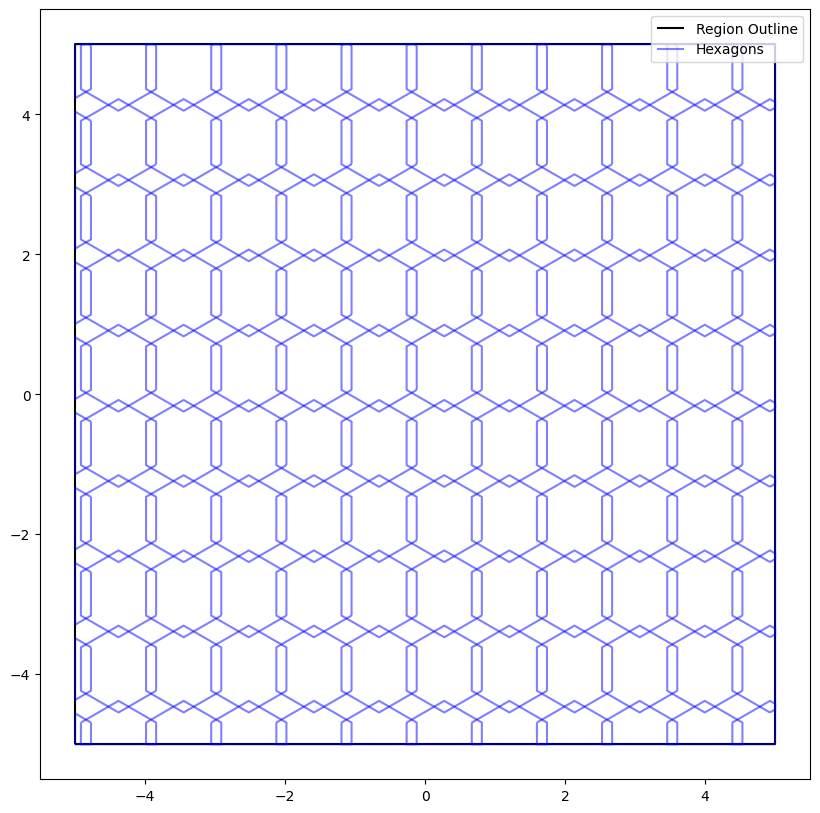

In [1]:
import geopandas as gpd
from shapely.geometry import Polygon, Point
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate hexagon side length from area
def calculate_hex_side_length(target_area):
    """
    Calculate the side length of a hexagon given the target area.
    Formula: Area = (3 * sqrt(3) * s^2) / 2, solve for s.
    """
    return np.sqrt((2 * target_area) / (3 * np.sqrt(3)))

# Function to generate a hexagonal grid
def generate_hex_grid(polygon, target_area):
    """
    Generate a hexagonal grid that covers the polygon's bounding box.
    """
    hex_side_length = calculate_hex_side_length(target_area)
    hex_width = 2 * hex_side_length
    hex_height = np.sqrt(3) * hex_side_length

    # Get bounding box of the polygon
    minx, miny, maxx, maxy = polygon.bounds

    # Generate hexagon centers
    x_start = minx - hex_width
    x_end = maxx + hex_width
    y_start = miny - hex_height
    y_end = maxy + hex_height

    hexagons = []
    y = y_start
    row = 0

    while y < y_end:
        x = x_start + (hex_width * 0.75 * (row % 2))  # Offset every other row
        while x < x_end:
            # Create a hexagon centered at (x, y)
            hexagon = create_hexagon(x, y, hex_side_length)
            hexagons.append(hexagon)
            x += hex_width * 0.75
        y += hex_height
        row += 1

    # Clip hexagons to the polygon
    hexagons_clipped = [hexagon.intersection(polygon) for hexagon in hexagons if hexagon.intersects(polygon)]

    # Create a GeoDataFrame
    return gpd.GeoDataFrame({"geometry": hexagons_clipped})

# Helper function to create a hexagon
def create_hexagon(x_center, y_center, side_length):
    """
    Create a hexagon centered at (x_center, y_center) with a given side length.
    """
    angle_offset = np.pi / 6  # 30 degrees
    return Polygon([
        (
            x_center + side_length * np.cos(angle_offset + i * np.pi / 3),
            y_center + side_length * np.sin(angle_offset + i * np.pi / 3)
        )
        for i in range(6)
    ])

# Example usage
# Replace this with your actual polygon from the GeoTIFF region
example_polygon = Polygon([(-5, -5), (-5, 5), (5, 5), (5, -5)])

# Target area in square units (adjust based on your needs)
target_area = 1.0  # Replace with your target area

# Generate hexagonal grid
hex_grid = generate_hex_grid(example_polygon, target_area)

# Plot the result
fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [example_polygon]}).boundary.plot(ax=ax, color="black", label="Region Outline")
hex_grid.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Hexagons")
plt.legend()
plt.show()
